# Problem 1 - Regression Model Assessment, Smoothing, and Cross-Validation

This notebook solves the regression model assessment problem from the practice final.
It simulates a one-predictor nonlinear regression data set, compares polynomial regression,
spline regression, and LOWESS using k-fold cross-validation, returns a full MSE table, and plots
the selected fitted curve.


In [1]:
### IMPORTS
# Core data manipulation and numerical computing libraries.
import pandas as pd
import numpy as np

# Plotting utilities used for exploratory and final-fit plots.
import matplotlib.pyplot as plt
plt.style.use('default')

# Regression models, feature constructors, and cross-validation tools.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import SplineTransformer

# LOWESS provides a flexible local smoother for one-dimensional regression.
from statsmodels.nonparametric.smoothers_lowess import lowess


In [2]:
### GLOBAL VARS
# A single seed makes the simulation and fold assignment reproducible.
RANDOM_SEED = 123


## Generate Data

The mean function is nonlinear: `E[Y|X] = 2 + sin(3X)`. The noise term turns this smooth curve
into observed data, which creates a realistic prediction problem.


In [3]:
def make_sine_regression_data(n=120, noise=0.35, random_state=RANDOM_SEED):
    """Create a reproducible one-dimensional nonlinear regression data set."""

    # Use numpy's random generator so the same seed recreates the same data.
    rng = np.random.default_rng(random_state)

    # Draw sorted x values so fitted curves are easy to plot from left to right.
    x = np.sort(rng.uniform(0.0, 3.0, size=n))

    # Define the true nonlinear mean function and then add Gaussian noise.
    truth = 2.0 + np.sin(3.0 * x)
    y = truth + rng.normal(loc=0.0, scale=noise, size=n)

    # The first column is the predictor and the second column is the response, as requested.
    return pd.DataFrame({"x": x, "y": y, "truth": truth})


In [4]:
def plot_regression_data(dat, ax, title="Simulated nonlinear regression data"):
    """Plot observed data and the true simulation curve when it is available."""

    # Sort the points by x before drawing the truth line.
    order = np.argsort(dat["x"].to_numpy())

    # Show noisy observations used for model fitting and validation.
    ax.scatter(dat["x"], dat["y"], s=24, alpha=0.65, label="observed")

    # The truth column is available only because we simulated the data.
    if "truth" in dat.columns:
        ax.plot(
            dat["x"].to_numpy()[order],
            dat["truth"].to_numpy()[order],
            color="red",
            linewidth=2,
            label="truth",
        )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)


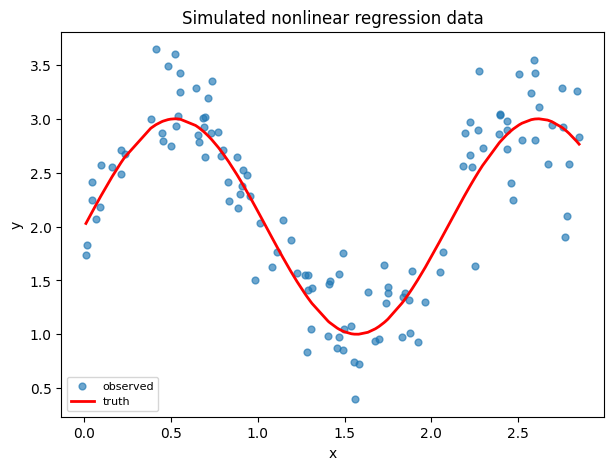

In [5]:
# Simulate the data set used for the rest of the notebook.
dat = make_sine_regression_data()

# Visualize the noisy observations and the true nonlinear mean curve.
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_regression_data(dat, ax)
plt.show()


## Model-Fitting Helpers

Each helper returns cross-validated MSE for one method and one tuning value. The functions are
written separately so the final comparison function is easy to read.


In [6]:
def _get_xy(dat):
    """Extract predictor matrix X and response vector y from the first two dataframe columns."""

    # The exam specifies that column 1 is the predictor and column 2 is the response.
    x_name = dat.columns[0]
    y_name = dat.columns[1]

    # Scikit-learn needs X to be two-dimensional, even with one predictor.
    X = dat[[x_name]].to_numpy()
    y = dat[y_name].to_numpy()

    return X, y


In [7]:
def fit_polynomial_cv(X, y, degree, cv):
    """Estimate prediction MSE for polynomial regression with a chosen degree."""

    # First create polynomial powers of x, then fit ordinary least squares.
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )

    # sklearn uses negative MSE for scoring, so multiply by -1 to get ordinary MSE.
    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.mean(mse_vals))


def fit_spline_cv(X, y, n_knots, cv, degree=3):
    """Estimate prediction MSE for cubic spline regression with a chosen knot count."""

    # SplineTransformer builds a flexible basis; linear regression estimates basis weights.
    model = make_pipeline(
        SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False),
        LinearRegression(),
    )

    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.mean(mse_vals))


def fit_lowess_cv(X, y, span, cv):
    """Estimate prediction MSE for LOWESS with a chosen smoothing span."""

    # LOWESS expects one-dimensional arrays for both x and y.
    x = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)
    mse_vals = []

    for train_idx, test_idx in cv.split(x):
        # Fit LOWESS on the training fold and predict directly at validation x values.
        preds = lowess(
            endog=y[train_idx],
            exog=x[train_idx],
            frac=span,
            it=0,
            xvals=x[test_idx],
        )

        mse_vals.append(mean_squared_error(y[test_idx], preds))

    return float(np.mean(mse_vals))


## Comparison Function

The requested function loops over each method and tuning grid, estimates prediction error by
k-fold cross-validation, identifies the best combination, optionally plots the selected curve, and
returns the full results table.


In [8]:
def _parse_tuning_value(tuning_value):
    """Convert stored tuning labels such as 'degree=3' into their numeric values."""

    return float(str(tuning_value).split("=")[1])


def _predict_selected_curve(dat, best_row):
    """Refit the selected method on all data and predict over a dense grid for plotting."""

    X, y = _get_xy(dat)
    x = X.reshape(-1)
    x_grid = np.linspace(x.min(), x.max(), 300)
    X_grid = x_grid.reshape(-1, 1)
    tuning_num = _parse_tuning_value(best_row["tuning_value"])

    if best_row["method"] == "Polynomial Regression":
        model = make_pipeline(
            PolynomialFeatures(degree=int(tuning_num), include_bias=False),
            LinearRegression(),
        )
        model.fit(X, y)
        y_grid = model.predict(X_grid)
    elif best_row["method"] == "Spline Regression":
        model = make_pipeline(
            SplineTransformer(n_knots=int(tuning_num), degree=3, include_bias=False),
            LinearRegression(),
        )
        model.fit(X, y)
        y_grid = model.predict(X_grid)
    elif best_row["method"] == "LOWESS":
        y_grid = lowess(endog=y, exog=x, frac=tuning_num, it=0, xvals=x_grid)
    else:
        raise ValueError(f"Unknown method: {best_row['method']}")

    return x_grid, y_grid


def compare_regression_methods(dat, degree_vec, spline_df_vec, span_vec, k=5, makePlot=True):
    """Compare nonlinear regression methods by k-fold CV and return a sorted MSE table."""

    # Extract the data once and reuse the same CV splits for all candidate models.
    X, y = _get_xy(dat)
    cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    results = []

    # Polynomial degree controls global curve flexibility.
    for degree in degree_vec:
        results.append({
            "method": "Polynomial Regression",
            "tuning_value": f"degree={degree}",
            "mean_cv_mse": fit_polynomial_cv(X, y, degree, cv),
        })

    # Spline complexity is represented here by the number of knots.
    for n_knots in spline_df_vec:
        results.append({
            "method": "Spline Regression",
            "tuning_value": f"n_knots={n_knots}",
            "mean_cv_mse": fit_spline_cv(X, y, n_knots, cv),
        })

    # LOWESS span is the fraction of data used in each local fit.
    for span in span_vec:
        results.append({
            "method": "LOWESS",
            "tuning_value": f"span={span}",
            "mean_cv_mse": fit_lowess_cv(X, y, span, cv),
        })

    # Sort so the best cross-validation result appears first.
    results_df = pd.DataFrame(results).sort_values("mean_cv_mse").reset_index(drop=True)
    best_row = results_df.iloc[0]

    print(
        f"Best combination: method={best_row['method']}, "
        f"tuning_value={best_row['tuning_value']}, "
        f"mean_cv_mse={best_row['mean_cv_mse']:.6f}"
    )

    if makePlot:
        # Refit the selected method on all data for visualization only.
        x_grid, y_grid = _predict_selected_curve(dat, best_row)
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
        plot_regression_data(dat, ax, title="Selected regression fit")
        ax.plot(
            x_grid,
            y_grid,
            color="black",
            linewidth=2.5,
            label=f"selected: {best_row['method']} ({best_row['tuning_value']})",
        )
        ax.legend(fontsize=8)
        plt.show()

    return results_df


## Demonstration

The grid below tests modest model sizes so the comparison runs quickly while still showing the
bias-variance tradeoff.


Best combination: method=LOWESS, tuning_value=span=0.12, mean_cv_mse=0.123377


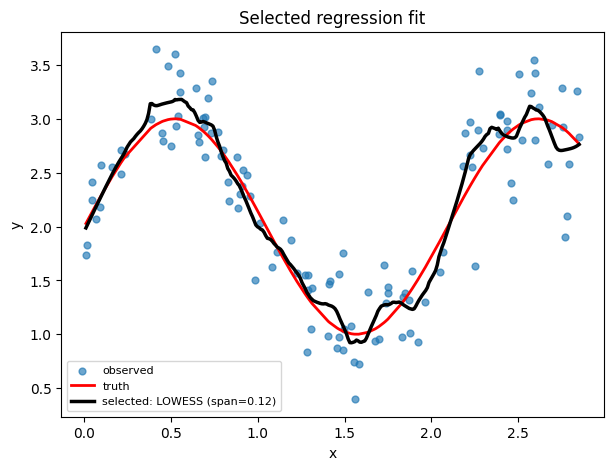

,method,tuning_value,mean_cv_mse
0,LOWESS,span=0.12,0.123377
1,LOWESS,span=0.16,0.123483
2,LOWESS,span=0.2,0.126843
3,Spline Regression,n_knots=7,0.128257
4,LOWESS,span=0.25,0.128977
5,Polynomial Regression,degree=6,0.129445
6,Polynomial Regression,degree=8,0.129932
7,Spline Regression,n_knots=6,0.130728
8,Polynomial Regression,degree=7,0.131102
9,Polynomial Regression,degree=10,0.131146


In [9]:
# Run the requested comparison on the simulated data.
regression_results = compare_regression_methods(
    dat=dat,
    degree_vec=range(1, 11),
    spline_df_vec=range(3, 11),
    span_vec=[0.08, 0.12, 0.16, 0.20, 0.25, 0.30, 0.40, 0.50, 0.70],
    k=5,
    makePlot=True,
)

# Display the full sorted table of method, tuning value, and mean CV MSE.
regression_results


## Interpretation

The selected method is the method/tuning combination with the smallest estimated prediction MSE.
Polynomial degree, spline knot count, and LOWESS span all control flexibility. Very simple models
have high bias because they cannot follow the nonlinear sine pattern. Very flexible models can have
high variance because they chase random noise. Cross-validation is used instead of training MSE
because training MSE almost always improves as flexibility increases, while CV estimates how well a
model predicts new observations.
